In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets, transforms, models
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from torch.optim import lr_scheduler

In [ ]:
print(torch.__version__)
print(torch.cuda.get_device_name())

1.8.0+cu101
Tesla K80


In [ ]:
!unzip '/content/drive/MyDrive/m_data.zip'

Streaming output truncated to the last 5000 lines.
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_116.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_118.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_126.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_134.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_141.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_168.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_175.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_183.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_221.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_222.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_87.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102428_cell_91.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102516_cell_104.png  
  inflating: cell/u/C236ThinF_IMG_20151127_102516_cell_13.png  
  inflating: cell/u/C236ThinF_IMG_20151127

In [ ]:
import os
import zipfile
from os import path
import shutil

# Define data path
data_path = '/content/cell/'
data_dir_list = os.listdir(data_path)
print(data_dir_list)

['u.txt', 'allLabel.txt', 'p', 'u', 'p.txt', 'all.txt']


In [ ]:
def showRawTrainingSamples(csv_filename):
  df = pd.read_csv(data_path + csv_filename)
  print(csv_filename)
  print(df.columns)
  return df

In [ ]:
a_csv = showRawTrainingSamples('p.txt')
c_csv = showRawTrainingSamples('u.txt')
a_csv

p.txt
Index(['image', 'label'], dtype='object')
u.txt
Index(['image', 'label'], dtype='object')


,image,label
0,C100P61ThinF_IMG_20150918_144104_cell_162.png,1
1,C100P61ThinF_IMG_20150918_144104_cell_163.png,1
2,C100P61ThinF_IMG_20150918_144104_cell_164.png,1
3,C100P61ThinF_IMG_20150918_144104_cell_165.png,1
4,C100P61ThinF_IMG_20150918_144104_cell_166.png,1
...,...,...
13774,C99P60ThinF_IMG_20150918_142334_cell_5.png,1
13775,C99P60ThinF_IMG_20150918_142334_cell_6.png,1
13776,C99P60ThinF_IMG_20150918_142334_cell_7.png,1
13777,C99P60ThinF_IMG_20150918_142334_cell_8.png,1


In [ ]:
total_csv = [a_csv, c_csv]
#total_csv = [a_csv,d_csv]
merged_csv = pd.concat(total_csv)
print(len(merged_csv))

merged_csv

27446


,image,label
0,C100P61ThinF_IMG_20150918_144104_cell_162.png,1
1,C100P61ThinF_IMG_20150918_144104_cell_163.png,1
2,C100P61ThinF_IMG_20150918_144104_cell_164.png,1
3,C100P61ThinF_IMG_20150918_144104_cell_165.png,1
4,C100P61ThinF_IMG_20150918_144104_cell_166.png,1
...,...,...
13662,C98P59ThinF_IMG_20150917_153600_cell_125.png,0
13663,C98P59ThinF_IMG_20150917_153600_cell_130.png,0
13664,C98P59ThinF_IMG_20150917_153600_cell_152.png,0
13665,C98P59ThinF_IMG_20150917_153600_cell_160.png,0


In [ ]:
TRAIN_PATH = 'trainn'
os.mkdir(TRAIN_PATH)

In [ ]:
def processImages(folder_name):
  src = data_path + folder_name + '/'
  dir_folders = os.listdir(src)
  for dir_name in dir_folders:
    file_name = os.path.join(src, dir_name)
    if os.path.isfile(file_name):
      shutil.copy(file_name, TRAIN_PATH)  

In [ ]:
processImages('p')
print('P Done')
processImages('u')
print('U Done')

P Done
U Done


In [ ]:
class Dataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.data = df
        self.root = root
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        item = self.data.iloc[index]
        
        path = self.root + "/" + item[0]
        image = Image.open(path).convert('L')
        label = item[1]
        
        if self.transform is not None:
            image = self.transform(image)
            
        return image, label

In [ ]:
mean = [0.5,]
std = [0.5, ]

train_transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
        transforms.Resize(28),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
])

valid_transform = transforms.Compose([
        transforms.Resize(28),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
])

train_data  = Dataset(merged_csv, TRAIN_PATH, train_transform)
test_data = Dataset(merged_csv, TRAIN_PATH, test_transform)
valid_data = Dataset(merged_csv, TRAIN_PATH, valid_transform)


print("Trainig Samples: ",len(train_data))
print("Trainig Samples: ",len(test_data))
print("Trainig Samples: ",len(valid_data))

Trainig Samples:  27446
Trainig Samples:  27446
Trainig Samples:  27446


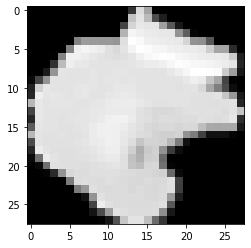

In [ ]:
## Displaying a MNIST Image

import matplotlib.pyplot as plt 
import numpy as np

show_img = train_data[27440][0].numpy().reshape(28, 28)
plt.imshow(show_img, cmap='gray')

In [ ]:
# One Image Size
print(train_data[27440][0].size())
print(train_data[27440][0].numpy().shape)
# First Image Label
print(train_data[27440][1])

torch.Size([1, 28, 28])
(1, 28, 28)
0


# Hyperparameters
batch_size = 64
num_iters = 30000
input_dim = 28*28 #num_features = 784
num_hidden = 1024,512,256,128
output_dim = 1
learning_rate = 0.0001
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
#batch size
#batch_size = 32
batch_size = 64
# split data 20% for testing
valid_size = 0.1
test_size = 0.2


# obtain training indices that will be used for validation
num_train = len(train_data)

# mix data
# index of num of train
indices = list(range(num_train))
# random the index
np.random.shuffle(indices)
split = int(np.floor(test_size * num_train))

indices_train_num=len(train_data)-split
indices_train=list(range(indices_train_num))
np.random.shuffle(indices_train)
split1 = int(np.floor(valid_size * indices_train_num))
# divied into two part
train_idx,valid_idx,test_idx = indices_train[split1:], indices_train[:split1], indices[:split]

# define the sampler
train_sampler = SubsetRandomSampler(train_idx)
test_sampler = SubsetRandomSampler(test_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare loaders
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=batch_size,
    sampler=train_sampler)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=batch_size,
    sampler=test_sampler)

valid_loader = torch.utils.data.DataLoader(
    valid_data, batch_size=batch_size,
    sampler=valid_sampler)

print("Train dataloader:{}".format(len(train_loader)))
print("Test dataloader:{}".format(len(test_loader)))
print("Valid dataloader:{}".format(len(valid_loader)))

Train dataloader:309
Test dataloader:86
Valid dataloader:35


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

# Hyperparameters
batch_size = 64
num_iters = 25000
input_dim = 28*28 # num_features = 784
num_hidden = 100
output_dim = 2

learning_rate = 0.1

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class DeepNeuralNetworkModel(nn.Module):
    def __init__(self):
        super().__init__()
        ### 1st hidden layer: 784 --> 100
        self.linear_1 = nn.Linear(28*28, 512)
        ### Non-linearity in 1st hidden layer
        self.relu_1 = nn.ReLU()

        ### 2nd hidden layer: 100 --> 100
        self.linear_2 = nn.Linear(512, 256)
        ### Non-linearity in 2nd hidden layer
        self.relu_2 = nn.LeakyReLU(0.1)


        self.linear_3 = nn.Linear(256, 128)
        ### Non-linearity in 2nd hidden layer
        self.relu_3 = nn.ReLU()
        

        ### Output layer: 100 --> 10
        self.linear_out = nn.Linear(128, 2)

    def forward(self, x):
        ### 1st hidden layer
        out  = self.linear_1(x)
        ### Non-linearity in 1st hidden layer
        out = self.relu_1(out)
        
        ### 2nd hidden layer
        out  = self.linear_2(out)
        ### Non-linearity in 2nd hidden layer
        out = self.relu_2(out)

        ### 2nd hidden layer
        out  = self.linear_3(out)
        ### Non-linearity in 2nd hidden layer
        out = self.relu_3(out)
        
        # Linear layer (output)
        probas  = self.linear_out(out)
        return probas

# INSTANTIATE MODEL CLASS

model = DeepNeuralNetworkModel()
# To enable GPU


# INSTANTIATE LOSS & OPTIMIZER CLASS

criterion = nn.CrossEntropyLoss()
#criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

iter = 0
iteration_loss=[]
iteration_accuracy=[]
num_epochs=40
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        images = images.view(-1, 28*28)
        labels = labels

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        outputs = model(images) 

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in valid_loader:
               
                images = images.view(-1, 28*28)
                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs, 1)

                # Total number of labels
                total += labels.size(0)


                # Total correct predictions
                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum() 
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total


            # Print Loss
            iteration_loss.append(loss.item())
            iteration_accuracy.append(accuracy)
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 0.6214468479156494. Accuracy: 60.82004555808656
Iteration: 1000. Loss: 0.4939630627632141. Accuracy: 66.42369020501138
Iteration: 1500. Loss: 0.575783371925354. Accuracy: 67.65375854214123
Iteration: 2000. Loss: 0.5161711573600769. Accuracy: 68.20045558086561
Iteration: 2500. Loss: 0.47015678882598877. Accuracy: 68.9749430523918
Iteration: 3000. Loss: 0.5121581554412842. Accuracy: 69.65831435079727
Iteration: 3500. Loss: 0.5586901307106018. Accuracy: 70.34168564920273
Iteration: 4000. Loss: 0.5059048533439636. Accuracy: 69.97722095671982
Iteration: 4500. Loss: 0.48883476853370667. Accuracy: 72.07289293849658
Iteration: 5000. Loss: 0.608248233795166. Accuracy: 71.61731207289294
Iteration: 5500. Loss: 0.5532267093658447. Accuracy: 71.84510250569475
Iteration: 6000. Loss: 0.37324240803718567. Accuracy: 72.9384965831435
Iteration: 6500. Loss: 0.5427346229553223. Accuracy: 71.70842824601367
Iteration: 7000. Loss: 0.4726378321647644. Accuracy: 72.66514806378132
Iteratio

[0.6214468479156494, 0.4939630627632141, 0.575783371925354, 0.5161711573600769, 0.47015678882598877, 0.5121581554412842, 0.5586901307106018, 0.5059048533439636, 0.48883476853370667, 0.608248233795166, 0.5532267093658447, 0.37324240803718567, 0.5427346229553223, 0.4726378321647644, 0.4872967302799225, 0.4182968735694885, 0.43747678399086, 0.38158994913101196, 0.40226802229881287, 0.40272825956344604, 0.40754935145378113, 0.32715609669685364, 0.4603881537914276, 0.4596930742263794]


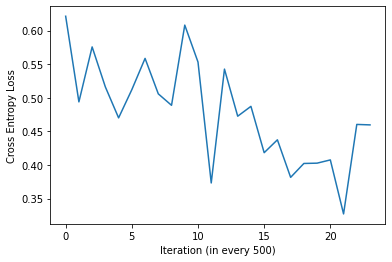

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

print (iteration_loss)
plt.plot(iteration_loss)
plt.ylabel('Cross Entropy Loss')
plt.xlabel('Iteration (in every 500)')
plt.show()

[60.82004555808656, 66.42369020501138, 67.65375854214123, 68.20045558086561, 68.9749430523918, 69.65831435079727, 70.34168564920273, 69.97722095671982, 72.07289293849658, 71.61731207289294, 71.84510250569475, 72.9384965831435, 71.70842824601367, 72.66514806378132, 72.9384965831435, 72.9384965831435, 73.80410022779043, 73.39407744874715, 72.52847380410023, 74.07744874715262, 74.16856492027335, 74.66970387243735, 74.94305239179954, 74.94305239179954]


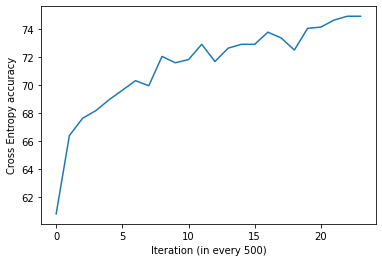

In [ ]:
print (iteration_accuracy)
plt.plot(iteration_accuracy)
plt.ylabel('Cross Entropy accuracy')
plt.xlabel('Iteration (in every 500)')
plt.show()

In [ ]:
def get_predictions(model, data_loader):
  model = model.eval()
  predictions = []
  real_values = []
  with torch.no_grad():
    for inputs, labels in data_loader:
      inputs = inputs.view(-1,28*28)
      labels = labels

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      predictions.extend(preds)
      real_values.extend(labels)
  predictions = torch.as_tensor(predictions).cpu()
  real_values = torch.as_tensor(real_values).cpu()
  return predictions, real_values

In [ ]:
y_pred, y_test = get_predictions(model, test_loader)

In [ ]:
class_names = ['parasitized','uninfected']

class_indices = [0, 1]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 parasitized       0.83      0.69      0.75      2737
  uninfected       0.73      0.86      0.79      2752

    accuracy                           0.77      5489
   macro avg       0.78      0.77      0.77      5489
weighted avg       0.78      0.77      0.77      5489



In [ ]:
def show_confusion_matrix(confusion_matrix, class_names):

  cm = confusion_matrix.copy()

  cell_counts = cm.flatten()

  cm_row_norm = cm / cm.sum(axis=1)[:, np.newaxis]

  row_percentages = ["{0:.2f}".format(value) for value in cm_row_norm.flatten()]

  cell_labels = [f"{cnt}\n{per}" for cnt, per in zip(cell_counts, row_percentages)]
  cell_labels = np.asarray(cell_labels).reshape(cm.shape[0], cm.shape[1])

  df_cm = pd.DataFrame(cm_row_norm, index=class_names, columns=class_names)

  hmap = sns.heatmap(df_cm, annot=cell_labels, fmt="", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True Sign')
  plt.xlabel('Predicted Sign');

In [ ]:
import seaborn as sns

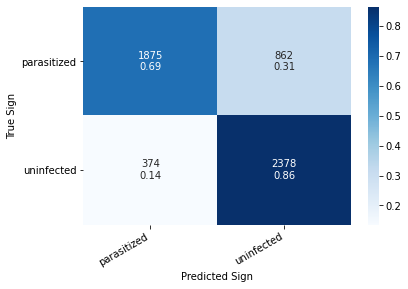

In [ ]:
cm = confusion_matrix(y_test, y_pred)
show_confusion_matrix(cm, class_names)

In [ ]:
root_path = '/content/drive/My Drive/'

In [ ]:
save_model = True

if save_model is True:
    # Saves only parameters
    # wights & biases
    torch.save(model.state_dict(), root_path + 'Malaria.pkl')

In [ ]:
load_model = True

if load_model is True:
    model.load_state_dict(torch.load(root_path + 'Malaria.pkl'))
    print('Trained Model Loaded')

Trained Model Loaded


0
0
0
0
0
1
1
0
1
1


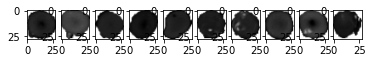

In [ ]:
for images, labels in test_loader:
    break
    
fig, ax = plt.subplots(1, 10)
for i in range(10):
    ax[i].imshow(images[i].view(28, 28), cmap=matplotlib.cm.binary)
    print(int(labels[i]))

plt.show()

In [ ]:
predictions = model.forward(images[:10].view(-1, 28*28))
predictions = torch.argmax(predictions, dim=1)
print('Predicted labels', predictions.cpu().numpy())

Predicted labels [0 0 0 0 0 1 0 0 0 1]


In [ ]:
with torch.no_grad():
  y_predicted=model.forward(images[:].view(-1, 28*28))
  y_predicted_cls = torch.argmax(y_predicted, dim=1)
  #print(y_predicted_cls)
  acc=y_predicted_cls.eq(labels[:]).sum()/float(labels.shape[0])
  print(f'accuracy={acc:.4f}')

  #print(labels[10:20])

accuracy=0.8281


In [ ]:
batch_size = 64
# split data 20% for testing
valid_size = 0.1
test_size = 0.2

In [ ]:
# obtain training indices that will be used for validation
num_train = len(train_data)

# mix data
# index of num of train
indices = list(range(num_train))
# random the index
np.random.shuffle(indices)
split = int(np.floor(test_size * num_train))
split1 = int(np.floor(valid_size * num_train))
# divied into two part
train_idx, test_idx, valid_idx = indices[split:], indices[:split], indices[:split1]

# define the sampler
train_sampler = SubsetRandomSampler(train_idx)
test_sampler = SubsetRandomSampler(test_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare loaders
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=batch_size,
    sampler=train_sampler)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=batch_size,
    sampler=test_sampler)

valid_loader = torch.utils.data.DataLoader(
    valid_data, batch_size=batch_size,
    sampler=valid_sampler)

print("Train dataloader:{}".format(len(train_loader)))
print("Test dataloader:{}".format(len(test_loader)))
print("Valid dataloader:{}".format(len(valid_loader)))

Train dataloader:344
Test dataloader:86
Valid dataloader:43


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

# Hyperparameters
num_iters = 15000
input_dim = 28*28 # num_features = 784
num_hidden1 = 1024
num_hidden2 = 560
num_hidden3 = 256
output_dim = 2

learning_rate = 0.0001



class DeepNeuralNetworkModel_(nn.Module):
    def __init__(self, input_size, num_classes, num_hidden1,num_hidden2,num_hidden3):
        super().__init__()
        ### 1st hidden layer: 784 --> 100
        self.linear_1 = nn.Linear(input_size, num_hidden1)
        ### Non-linearity in 1st hidden layer
        self.relu_1 = nn.ReLU()

        ### 2nd hidden layer: 100 --> 100
        self.linear_2 = nn.Linear(num_hidden1, num_hidden2)
        ### Non-linearity in 2nd hidden layer
        self.relu_2 = nn.ReLU()

        ### Output layer: 100 --> 10
        self.linear_out = nn.Linear(num_hidden2, num_classes)

    def forward(self, x):
        ### 1st hidden layer
        out  = self.linear_1(x)
        ### Non-linearity in 1st hidden layer
        out = self.relu_1(out)
        
        ### 2nd hidden layer
        out  = self.linear_2(out)
        ### Non-linearity in 2nd hidden layer
        out = self.relu_2(out)
        
        # Linear layer (output)
        probas  = self.linear_out(out)
        return probas

# INSTANTIATE MODEL CLASS

model = DeepNeuralNetworkModel_(input_size = input_dim,
                               num_classes = output_dim,
                               num_hidden1 = num_hidden1,
                               num_hidden2 = num_hidden2,
                               num_hidden3 = num_hidden3)
# To enable GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# INSTANTIATE LOSS & OPTIMIZER CLASS

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

iteration_loss = []
iteration_accuracy = []

iter = 0
num_epochs = num_iters / (len(train_data)/ batch_size)
num_epochs = int(num_epochs)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        images = images.view(-1, 28*28).to(device)
        labels = labels.to(device)

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        outputs = model(images) 

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in valid_loader:
               
                images = images.view(-1, 28*28).to(device)

                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs, 1)

                # Total number of labels
                total += labels.size(0)


                # Total correct predictions
                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum() 
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total
            iteration_accuracy.append(accuracy)
            iteration_loss.append(loss.item())
            # Print Loss
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 0.5217841863632202. Accuracy: 72.3006833712984
Iteration: 1000. Loss: 0.5131897926330566. Accuracy: 73.0751708428246
Iteration: 1500. Loss: 0.5214089751243591. Accuracy: 74.30523917995444
Iteration: 2000. Loss: 0.41208523511886597. Accuracy: 75.125284738041
Iteration: 2500. Loss: 0.41140565276145935. Accuracy: 75.39863325740319
Iteration: 3000. Loss: 0.44807079434394836. Accuracy: 76.81093394077449
Iteration: 3500. Loss: 0.3362269699573517. Accuracy: 75.44419134396355
Iteration: 4000. Loss: 0.3038039803504944. Accuracy: 76.17312072892939
Iteration: 4500. Loss: 0.40710610151290894. Accuracy: 76.71981776765377
Iteration: 5000. Loss: 0.286788672208786. Accuracy: 75.85421412300683
Iteration: 5500. Loss: 0.31364601850509644. Accuracy: 77.1753986332574
Iteration: 6000. Loss: 0.17588141560554504. Accuracy: 76.21867881548975
Iteration: 6500. Loss: 0.3664633631706238. Accuracy: 76.62870159453303
Iteration: 7000. Loss: 0.15083420276641846. Accuracy: 76.44646924829158
Iterat

[0.5217841863632202, 0.5131897926330566, 0.5214089751243591, 0.41208523511886597, 0.41140565276145935, 0.44807079434394836, 0.3362269699573517, 0.3038039803504944, 0.40710610151290894, 0.286788672208786, 0.31364601850509644, 0.17588141560554504, 0.3664633631706238, 0.15083420276641846, 0.09004749357700348, 0.1786661446094513, 0.15604466199874878, 0.15059317648410797, 0.14082477986812592, 0.030684836208820343, 0.10868316888809204]


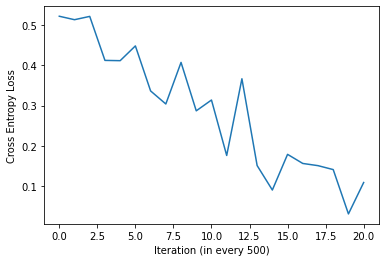

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

print (iteration_loss)
plt.plot(iteration_loss)
plt.ylabel('Cross Entropy Loss')
plt.xlabel('Iteration (in every 500)')
plt.show()

[72.3006833712984, 73.0751708428246, 74.30523917995444, 75.125284738041, 75.39863325740319, 76.81093394077449, 75.44419134396355, 76.17312072892939, 76.71981776765377, 75.85421412300683, 77.1753986332574, 76.21867881548975, 76.62870159453303, 76.44646924829158, 77.12984054669704, 77.67653758542141, 78.13211845102505, 77.12984054669704, 78.04100227790433, 78.22323462414579, 77.1753986332574]


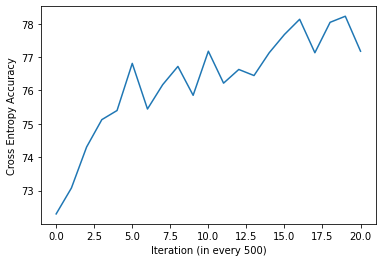

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

print (iteration_accuracy)
plt.plot(iteration_accuracy)
plt.ylabel('Cross Entropy Accuracy')
plt.xlabel('Iteration (in every 500)')
plt.show()

In [ ]:
def get_predictions(model, data_loader):
  model = model.eval()
  predictions = []
  real_values = []
  with torch.no_grad():
    for inputs, labels in data_loader:
      inputs = inputs.view(-1,28*28).to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      predictions.extend(preds)
      real_values.extend(labels)
  predictions = torch.as_tensor(predictions).cpu()
  real_values = torch.as_tensor(real_values).cpu()
  return predictions, real_values

In [ ]:
y_pred, y_test = get_predictions(model, test_loader)

In [ ]:
class_names = ['parasitized','uninfected']

class_indices = [0, 1]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 parasitized       0.98      0.75      0.85      2712
  uninfected       0.80      0.99      0.88      2777

    accuracy                           0.87      5489
   macro avg       0.89      0.87      0.87      5489
weighted avg       0.89      0.87      0.87      5489



In [ ]:
def show_confusion_matrix(confusion_matrix, class_names):

  cm = confusion_matrix.copy()

  cell_counts = cm.flatten()

  cm_row_norm = cm / cm.sum(axis=1)[:, np.newaxis]

  row_percentages = ["{0:.2f}".format(value) for value in cm_row_norm.flatten()]

  cell_labels = [f"{cnt}\n{per}" for cnt, per in zip(cell_counts, row_percentages)]
  cell_labels = np.asarray(cell_labels).reshape(cm.shape[0], cm.shape[1])

  df_cm = pd.DataFrame(cm_row_norm, index=class_names, columns=class_names)

  hmap = sns.heatmap(df_cm, annot=cell_labels, fmt="", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True Sign')
  plt.xlabel('Predicted Sign');

In [ ]:
import seaborn as sns

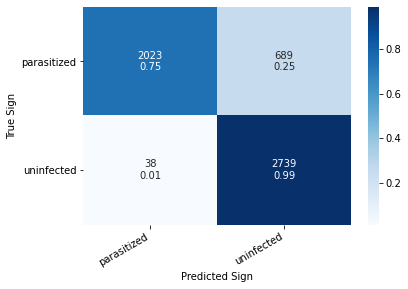

In [ ]:
cm = confusion_matrix(y_test, y_pred)
show_confusion_matrix(cm, class_names)

In [ ]:
root_path = '/content/drive/My Drive/'

In [ ]:
save_model = True

if save_model is True:
    # Saves only parameters
    # wights & biases
    torch.save(model.state_dict(), root_path + 'Malaria2.pkl')

In [ ]:
load_model = True

if load_model is True:
    model.load_state_dict(torch.load(root_path + 'Malaria2.pkl'))
    print('Trained Model Loaded')

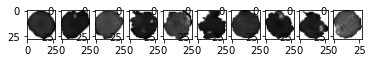

In [ ]:
for images, labels in test_loader:
    break
    
fig, ax = plt.subplots(1, 10)
for i in range(10):
    ax[i].imshow(images[i].view(28, 28), cmap=matplotlib.cm.binary)

plt.show()

In [ ]:
predictions = model.forward(images[:10].view(-1, 28*28).to(device))
predictions = torch.argmax(predictions, dim=1)
print('Predicted labels', predictions.cpu().numpy())

Predicted labels [0 1 1 1 1 1 1 1 1 1]


In [ ]:
with torch.no_grad():
  y_predicted=model.forward(images[:].view(-1, 28*28).to(device))
  y_predicted_cls = torch.argmax(y_predicted, dim=1)
  #print(y_predicted_cls)
  acc=y_predicted_cls.eq(labels[:].to(device)).sum()/float(labels.shape[0])
  print(f'accuracy={acc:.4f}')

  #print(labels[10:20])

accuracy=0.8906


In [ ]:
batch_size = 64
# split data 20% for testing
valid_size = 0.1
test_size = 0.2

In [ ]:
# obtain training indices that will be used for validation
num_train = len(train_data)

# mix data
# index of num of train
indices = list(range(num_train))
# random the index
np.random.shuffle(indices)
split = int(np.floor(test_size * num_train))
split1 = int(np.floor(valid_size * num_train))
# divied into two part
train_idx, test_idx, valid_idx = indices[split:], indices[:split], indices[:split1]

# define the sampler
train_sampler = SubsetRandomSampler(train_idx)
test_sampler = SubsetRandomSampler(test_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare loaders
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=batch_size,
    sampler=train_sampler)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=batch_size,
    sampler=test_sampler)

valid_loader = torch.utils.data.DataLoader(
    valid_data, batch_size=batch_size,
    sampler=valid_sampler)

print("Train dataloader:{}".format(len(train_loader)))
print("Test dataloader:{}".format(len(test_loader)))
print("Valid dataloader:{}".format(len(valid_loader)))

Train dataloader:344
Test dataloader:86
Valid dataloader:43


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

# Hyperparameters
num_iters = 21000
input_dim = 28*28 # num_features = 784
num_hidden1 = 1000
num_hidden2 = 605
num_hidden3 = 200
output_dim = 2

learning_rate = 0.0001



class DeepNeuralNetworkModel_(nn.Module):
    def __init__(self, input_size, num_classes, num_hidden1,num_hidden2,num_hidden3):
        super().__init__()
        ### 1st hidden layer: 784 --> 100
        self.linear_1 = nn.Linear(input_size, num_hidden1)
        ### Non-linearity in 1st hidden layer
        self.tanh_1 = nn.Tanh()

        ### 2nd hidden layer: 100 --> 100
        self.linear_2 = nn.Linear(num_hidden1, num_hidden2)
        ### Non-linearity in 2nd hidden layer
        self.relu_2 = nn.ReLU()

        ### Output layer: 100 --> 10
        self.linear_out = nn.Linear(num_hidden2, num_classes)

    def forward(self, x):
        ### 1st hidden layer
        out  = self.linear_1(x)
        ### Non-linearity in 1st hidden layer
        out = self.tanh_1(out)
        
        ### 2nd hidden layer
        out  = self.linear_2(out)
        ### Non-linearity in 2nd hidden layer
        out = self.relu_2(out)
        
        # Linear layer (output)
        probas  = self.linear_out(out)
        return probas

# INSTANTIATE MODEL CLASS

model = DeepNeuralNetworkModel_(input_size = input_dim,
                               num_classes = output_dim,
                               num_hidden1 = num_hidden1,
                               num_hidden2 = num_hidden2,
                               num_hidden3 = num_hidden3)
# To enable GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# INSTANTIATE LOSS & OPTIMIZER CLASS

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

iteration_loss = []
iteration_accuracy = []

iter = 0
num_epochs = num_iters / (len(train_data)/ batch_size)
num_epochs = int(num_epochs)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        images = images.view(-1, 28*28).to(device)
        labels = labels.to(device)

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        outputs = model(images) 

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in valid_loader:
               
                images = images.view(-1, 28*28).to(device)

                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs, 1)

                # Total number of labels
                total += labels.size(0)


                # Total correct predictions
                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum() 
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total
            iteration_accuracy.append(accuracy)
            iteration_loss.append(loss.item())
            # Print Loss
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 0.5779888033866882. Accuracy: 67.63848396501457
Iteration: 1000. Loss: 0.5803343057632446. Accuracy: 66.25364431486881
Iteration: 1500. Loss: 0.5344333648681641. Accuracy: 69.46064139941691
Iteration: 2000. Loss: 0.4349490702152252. Accuracy: 69.86151603498543
Iteration: 2500. Loss: 0.5080690979957581. Accuracy: 67.67492711370262
Iteration: 3000. Loss: 0.48677414655685425. Accuracy: 70.51749271137027
Iteration: 3500. Loss: 0.5445723533630371. Accuracy: 69.6064139941691
Iteration: 4000. Loss: 0.4459776282310486. Accuracy: 71.100583090379
Iteration: 4500. Loss: 0.45545896887779236. Accuracy: 70.95481049562682
Iteration: 5000. Loss: 0.3814452588558197. Accuracy: 71.7201166180758
Iteration: 5500. Loss: 0.4768083393573761. Accuracy: 70.91836734693878
Iteration: 6000. Loss: 0.3666648268699646. Accuracy: 70.18950437317784
Iteration: 6500. Loss: 0.41055017709732056. Accuracy: 70.77259475218659
Iteration: 7000. Loss: 0.3239589333534241. Accuracy: 71.13702623906705
Iteratio

[0.5779888033866882, 0.5803343057632446, 0.5344333648681641, 0.4349490702152252, 0.5080690979957581, 0.48677414655685425, 0.5445723533630371, 0.4459776282310486, 0.45545896887779236, 0.3814452588558197, 0.4768083393573761, 0.3666648268699646, 0.41055017709732056, 0.3239589333534241, 0.3844129145145416, 0.3944772183895111, 0.29133057594299316, 0.3924739360809326, 0.34267768263816833, 0.30306196212768555, 0.2949311137199402, 0.3302343189716339, 0.32726770639419556, 0.306109219789505, 0.20549370348453522, 0.2616976797580719, 0.2079407423734665, 0.1742580384016037, 0.18278689682483673, 0.2026851326227188, 0.16769972443580627, 0.16650128364562988, 0.15477576851844788]


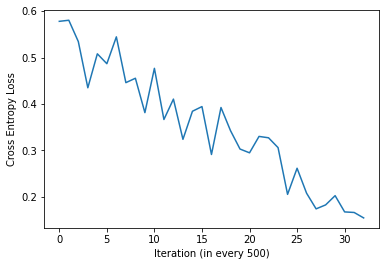

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

print (iteration_loss)
plt.plot(iteration_loss)
plt.ylabel('Cross Entropy Loss')
plt.xlabel('Iteration (in every 500)')
plt.show()

[67.63848396501457, 66.25364431486881, 69.46064139941691, 69.86151603498543, 67.67492711370262, 70.51749271137027, 69.6064139941691, 71.100583090379, 70.95481049562682, 71.7201166180758, 70.91836734693878, 70.18950437317784, 70.77259475218659, 71.13702623906705, 70.88192419825073, 70.6268221574344, 70.80903790087464, 72.01166180758017, 71.865889212828, 70.88192419825073, 71.90233236151603, 72.48542274052478, 71.7930029154519, 71.7201166180758, 72.08454810495627, 71.6472303206997, 72.08454810495627, 71.39212827988338, 72.3396501457726, 72.12099125364432, 72.3396501457726, 72.44897959183673, 71.7930029154519]


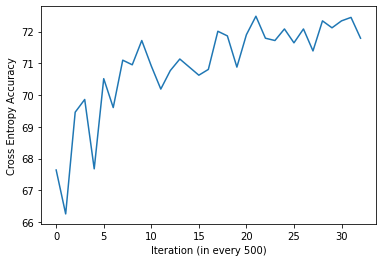

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

print (iteration_accuracy)
plt.plot(iteration_accuracy)
plt.ylabel('Cross Entropy Accuracy')
plt.xlabel('Iteration (in every 500)')
plt.show()

In [ ]:
def get_predictions(model, data_loader):
  model = model.eval()
  predictions = []
  real_values = []
  with torch.no_grad():
    for inputs, labels in data_loader:
      inputs = inputs.view(-1,28*28).to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      predictions.extend(preds)
      real_values.extend(labels)
  predictions = torch.as_tensor(predictions).cpu()
  real_values = torch.as_tensor(real_values).cpu()
  return predictions, real_values

In [ ]:
y_pred, y_test = get_predictions(model, test_loader)

In [ ]:
class_names = ['parasitized','uninfected']

class_indices = [0, 1]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 parasitized       0.74      0.70      0.72      2759
  uninfected       0.71      0.76      0.73      2730

    accuracy                           0.73      5489
   macro avg       0.73      0.73      0.73      5489
weighted avg       0.73      0.73      0.73      5489



In [ ]:
def show_confusion_matrix(confusion_matrix, class_names):

  cm = confusion_matrix.copy()

  cell_counts = cm.flatten()

  cm_row_norm = cm / cm.sum(axis=1)[:, np.newaxis]

  row_percentages = ["{0:.2f}".format(value) for value in cm_row_norm.flatten()]

  cell_labels = [f"{cnt}\n{per}" for cnt, per in zip(cell_counts, row_percentages)]
  cell_labels = np.asarray(cell_labels).reshape(cm.shape[0], cm.shape[1])

  df_cm = pd.DataFrame(cm_row_norm, index=class_names, columns=class_names)

  hmap = sns.heatmap(df_cm, annot=cell_labels, fmt="", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True Sign')
  plt.xlabel('Predicted Sign');

In [ ]:
import seaborn as sns

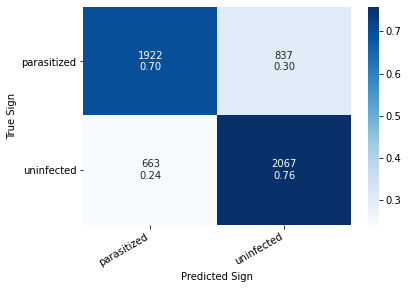

In [ ]:
cm = confusion_matrix(y_test, y_pred)
show_confusion_matrix(cm, class_names)

In [ ]:
root_path = '/content/drive/My Drive/'

In [ ]:
save_model = True

if save_model is True:
    # Saves only parameters
    # wights & biases
    torch.save(model.state_dict(), root_path + 'Malaria3.pkl')

In [ ]:
load_model = True

if load_model is True:
    model.load_state_dict(torch.load(root_path + 'Malaria3.pkl'))
    print('Trained Model Loaded')

Trained Model Loaded


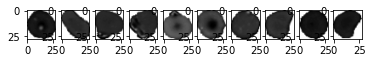

In [ ]:
for images, labels in test_loader:
    break
    
fig, ax = plt.subplots(1, 10)
for i in range(10):
    ax[i].imshow(images[i].view(28, 28), cmap=matplotlib.cm.binary)

plt.show()

In [ ]:
predictions = model.forward(images[:10].view(-1, 28*28).to(device))
predictions = torch.argmax(predictions, dim=1)
print('Predicted labels', predictions.cpu().numpy())

Predicted labels [0 0 1 1 1 0 1 1 0 0]


In [ ]:
with torch.no_grad():
  y_predicted=model.forward(images[:].view(-1, 28*28).to(device))
  y_predicted_cls = torch.argmax(y_predicted, dim=1)
  #print(y_predicted_cls)
  acc=y_predicted_cls.eq(labels[:].to(device)).sum()/float(labels.shape[0])
  print(f'accuracy={acc:.4f}')

  #print(labels[10:20])

accuracy=0.8125


# WorkFlow of Methodology

We characterize the complete work flow into nine steps.

1. Preprocessing of CSV data and corresponding image data.
2. Normalize the input data.
3. Train-Test split.
4. Setting up hyperparameters.
5. Initialize model, loss and optimizer.
6. Training data and evaluation on validation data in terms of loss and accuracy.
7. Save Model.
8. Build Binary class classification model
9. Prediction from test dataset